In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns

In [26]:
df = pd.read_csv(r"C:\Users\sulai\Desktop\Python\MedScan\Datasets\dementiaStudy.csv")
df.head()

,ID,age,gender,dementia,dementia_all,educationyears,EF,PS,Global,diabetes,...,hypercholesterolemia,lacunes_num,fazekas_cat,study,study1,SVD Simple Score,SVD Amended Score,Fazekas,lac_count,CMB_count
0,1,52.67,male,0.0,0,11.0,-2.403333,-1.290000,-1.287000,0,...,Yes,more-than-zero,2 to 3,scans,scans,3.0,7.0,3,>5,>=1
1,10,64.58,male,0.0,0,10.0,1.280000,0.360000,0.744000,0,...,Yes,more-than-zero,0 to 1,scans,scans,2.0,3.0,1,1 to 2,>=1
2,100,74.92,male,0.0,0,8.0,-1.440000,-1.520000,-0.922000,0,...,Yes,more-than-zero,0 to 1,scans,scans,1.0,2.0,1,1 to 2,0
3,101,74.83,male,1.0,1,9.0,NaN,-2.136271,-1.301102,0,...,Yes,more-than-zero,2 to 3,scans,scans,2.0,4.0,2,3 to 5,0
4,102,79.25,male,0.0,0,10.0,-0.920000,-1.493333,-0.924000,0,...,Yes,more-than-zero,2 to 3,scans,scans,2.0,3.0,2,1 to 2,0


In [27]:
df.describe()
print("------------------------")
df.info()

------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1842 entries, 0 to 1841
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1842 non-null   int64  
 1   age                   1842 non-null   float64
 2   gender                1842 non-null   object 
 3   dementia              1808 non-null   float64
 4   dementia_all          1842 non-null   int64  
 5   educationyears        1842 non-null   float64
 6   EF                    1634 non-null   float64
 7   PS                    1574 non-null   float64
 8   Global                1534 non-null   float64
 9   diabetes              1842 non-null   int64  
 10  smoking               1831 non-null   object 
 11  hypertension          1842 non-null   object 
 12  hypercholesterolemia  1842 non-null   object 
 13  lacunes_num           1842 non-null   object 
 14  fazekas_cat           1842 non-null   object 
 

In [28]:
df.isna().sum()

ID                        0
age                       0
gender                    0
dementia                 34
dementia_all              0
educationyears            0
EF                      208
PS                      268
Global                  308
diabetes                  0
smoking                  11
hypertension              0
hypercholesterolemia      0
lacunes_num               0
fazekas_cat               0
study                     0
study1                    0
SVD Simple Score        677
SVD Amended Score       677
Fazekas                   0
lac_count                 0
CMB_count                 0
dtype: int64

In [29]:
df.drop(['dementia','ID'],axis=1,inplace=True)

In [30]:
df.head()

,age,gender,dementia_all,educationyears,EF,PS,Global,diabetes,smoking,hypertension,hypercholesterolemia,lacunes_num,fazekas_cat,study,study1,SVD Simple Score,SVD Amended Score,Fazekas,lac_count,CMB_count
0,52.67,male,0,11.0,-2.403333,-1.290000,-1.287000,0,current-smoker,Yes,Yes,more-than-zero,2 to 3,scans,scans,3.0,7.0,3,>5,>=1
1,64.58,male,0,10.0,1.280000,0.360000,0.744000,0,ex-smoker,Yes,Yes,more-than-zero,0 to 1,scans,scans,2.0,3.0,1,1 to 2,>=1
2,74.92,male,0,8.0,-1.440000,-1.520000,-0.922000,0,never-smoker,Yes,Yes,more-than-zero,0 to 1,scans,scans,1.0,2.0,1,1 to 2,0
3,74.83,male,1,9.0,NaN,-2.136271,-1.301102,0,current-smoker,Yes,Yes,more-than-zero,2 to 3,scans,scans,2.0,4.0,2,3 to 5,0
4,79.25,male,0,10.0,-0.920000,-1.493333,-0.924000,0,ex-smoker,Yes,Yes,more-than-zero,2 to 3,scans,scans,2.0,3.0,2,1 to 2,0


In [31]:
df.isna().sum()

age                       0
gender                    0
dementia_all              0
educationyears            0
EF                      208
PS                      268
Global                  308
diabetes                  0
smoking                  11
hypertension              0
hypercholesterolemia      0
lacunes_num               0
fazekas_cat               0
study                     0
study1                    0
SVD Simple Score        677
SVD Amended Score       677
Fazekas                   0
lac_count                 0
CMB_count                 0
dtype: int64

In [32]:
df = df[['age','gender','dementia_all','educationyears',
         'EF','PS','Global','diabetes','smoking','hypertension']]

In [33]:
df.head()

,age,gender,dementia_all,educationyears,EF,PS,Global,diabetes,smoking,hypertension
0,52.67,male,0,11.0,-2.403333,-1.290000,-1.287000,0,current-smoker,Yes
1,64.58,male,0,10.0,1.280000,0.360000,0.744000,0,ex-smoker,Yes
2,74.92,male,0,8.0,-1.440000,-1.520000,-0.922000,0,never-smoker,Yes
3,74.83,male,1,9.0,NaN,-2.136271,-1.301102,0,current-smoker,Yes
4,79.25,male,0,10.0,-0.920000,-1.493333,-0.924000,0,ex-smoker,Yes


In [34]:
df['hypertension'] = df['hypertension'].replace({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].replace({'female': 1, 'male': 0})
df['smoking'] = df['smoking'].replace({'never-smoker': 0, 'ex-smoker':1, 'current-smoker':2})

C:\Users\sulai\AppData\Local\Temp\ipykernel_2768\1243421824.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['hypertension'] = df['hypertension'].replace({'Yes': 1, 'No': 0})
C:\Users\sulai\AppData\Local\Temp\ipykernel_2768\1243421824.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'female': 1, 'male': 0})
C:\Users\sulai\AppData\Local\Temp\ipykernel_2768\1243421824.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain t

In [35]:
df.head(10)

,age,gender,dementia_all,educationyears,EF,PS,Global,diabetes,smoking,hypertension
0,52.67,0,0,11.0,-2.403333,-1.290000,-1.287000,0,2.0,1
1,64.58,0,0,10.0,1.280000,0.360000,0.744000,0,1.0,1
2,74.92,0,0,8.0,-1.440000,-1.520000,-0.922000,0,0.0,1
3,74.83,0,1,9.0,NaN,-2.136271,-1.301102,0,2.0,1
4,79.25,0,0,10.0,-0.920000,-1.493333,-0.924000,0,1.0,1
5,62.75,0,0,24.0,-0.380000,-1.110000,-0.526667,0,1.0,1
6,76.00,0,0,19.0,0.610000,-0.403333,0.120000,0,0.0,1
7,69.67,1,0,12.0,0.730000,0.793333,0.672000,0,0.0,1
8,53.75,0,1,12.0,-3.086667,-2.616667,-2.178000,0,0.0,1
9,80.92,1,0,12.0,-0.060000,-0.100000,0.043000,0,0.0,0


In [36]:
df.isna().sum()

age                 0
gender              0
dementia_all        0
educationyears      0
EF                208
PS                268
Global            308
diabetes            0
smoking            11
hypertension        0
dtype: int64

In [37]:

ef_mean = df['EF'].mean()
ps_mean = df['PS'].mean()
global_mean = df['Global'].mean()
df['EF'].fillna(ef_mean, inplace=True)
df['PS'].fillna(ps_mean, inplace=True)
df['Global'].fillna(global_mean, inplace=True)
df['smoking'].fillna(0, inplace=True)

C:\Users\sulai\AppData\Local\Temp\ipykernel_2768\3766245175.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EF'].fillna(ef_mean, inplace=True)
C:\Users\sulai\AppData\Local\Temp\ipykernel_2768\3766245175.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

In [38]:
df.isna().sum()

age               0
gender            0
dementia_all      0
educationyears    0
EF                0
PS                0
Global            0
diabetes          0
smoking           0
hypertension      0
dtype: int64

Text(0.5, 1.0, 'EF and PS')

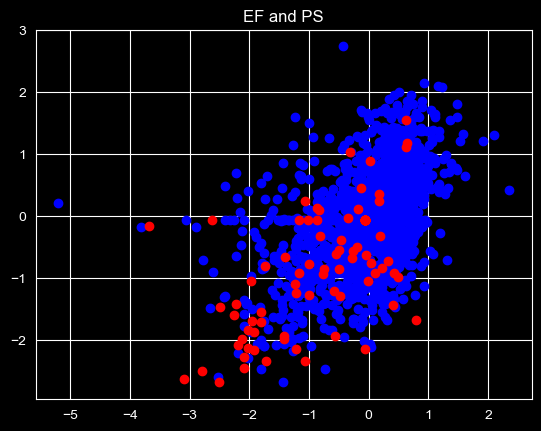

In [39]:
condition = df['dementia_all'] == 1

plt.scatter(df.loc[~condition,'EF'], df.loc[~condition,'PS'],color='blue',label='Dementia')
plt.scatter(df.loc[condition,'EF'], df.loc[condition,'PS'],color='red',label='Dementia')
plt.title('EF and PS')

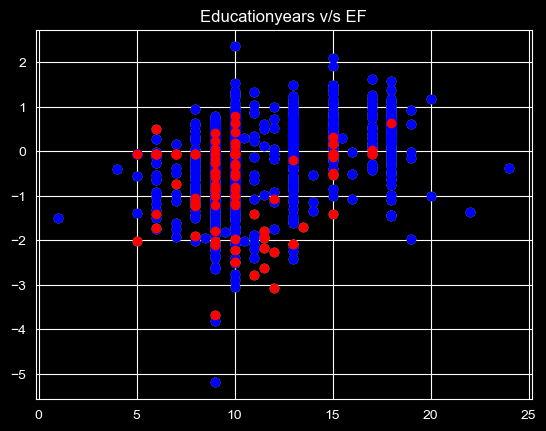

In [40]:
plt.scatter(df['educationyears'],df['EF'])
plt.scatter(df.loc[~condition,'educationyears'], df.loc[~condition,'EF'],color='blue',label='Dementia')
plt.scatter(df.loc[condition,'educationyears'], df.loc[condition,'EF'],color='red',label='Dementia')
plt.title('Educationyears v/s EF')
plt.show()

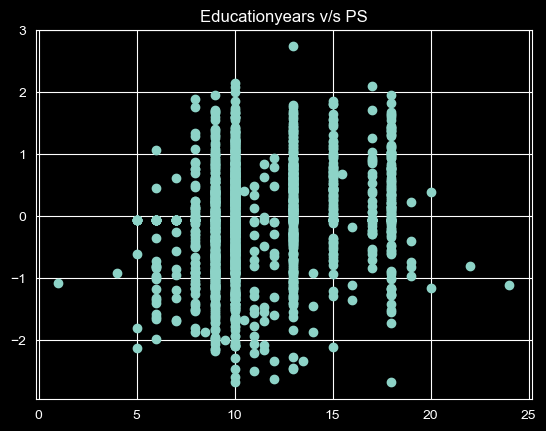

In [41]:
plt.scatter(df['educationyears'],df['PS'])
plt.title('Educationyears v/s PS')
plt.show()

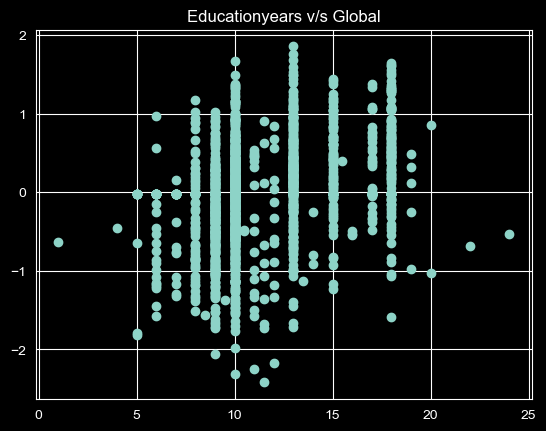

In [42]:
plt.scatter(df['educationyears'],df['Global'])
plt.title('Educationyears v/s Global')
plt.show()

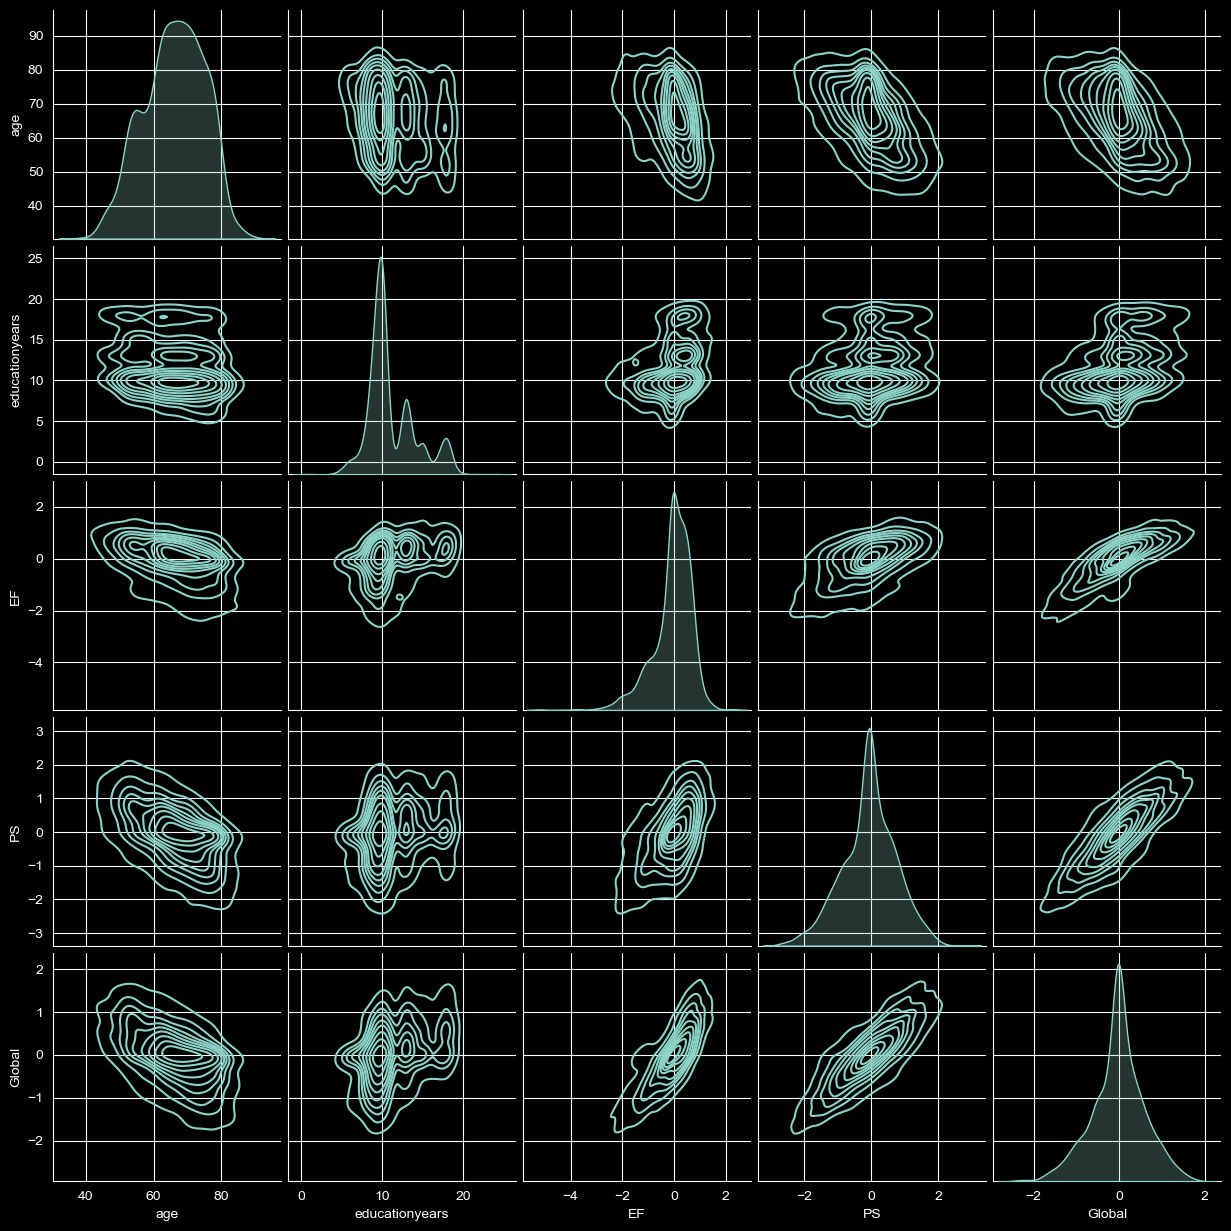

In [43]:
sns.pairplot(df[['age','educationyears','EF','PS','Global']],kind='kde',)

In [44]:
df.head(5)

,age,gender,dementia_all,educationyears,EF,PS,Global,diabetes,smoking,hypertension
0,52.67,0,0,11.0,-2.403333,-1.290000,-1.287000,0,2.0,1
1,64.58,0,0,10.0,1.280000,0.360000,0.744000,0,1.0,1
2,74.92,0,0,8.0,-1.440000,-1.520000,-0.922000,0,0.0,1
3,74.83,0,1,9.0,-0.063088,-2.136271,-1.301102,0,2.0,1
4,79.25,0,0,10.0,-0.920000,-1.493333,-0.924000,0,1.0,1


In [45]:
X = df.drop('dementia_all',axis=1)
X.head(5)

,age,gender,educationyears,EF,PS,Global,diabetes,smoking,hypertension
0,52.67,0,11.0,-2.403333,-1.290000,-1.287000,0,2.0,1
1,64.58,0,10.0,1.280000,0.360000,0.744000,0,1.0,1
2,74.92,0,8.0,-1.440000,-1.520000,-0.922000,0,0.0,1
3,74.83,0,9.0,-0.063088,-2.136271,-1.301102,0,2.0,1
4,79.25,0,10.0,-0.920000,-1.493333,-0.924000,0,1.0,1


In [46]:
y = df['dementia_all']
y.head(5)

0    0
1    0
2    0
3    1
4    0
Name: dementia_all, dtype: int64

In [47]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [53]:
pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': [None, 'balanced'],

}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

# 4. Fit the Grid Search
print("Starting Grid Search...")
grid_search.fit(x_train, y_train)

# 5. Best Model & Results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Recall Score: {grid_search.best_score_:.4f}")

# 6. Evaluate on Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

print("\n--- Test Set Evaluation ---")
print(f"Accuracy: {best_model.score(x_test, y_test):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Starting Grid Search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best Cross-Validation Recall Score: 0.2228

--- Test Set Evaluation ---
Accuracy: 0.9024
Recall (Sensitivity): 0.3143

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       518
           1       0.27      0.31      0.29        35

    accuracy                           0.90       553
   macro avg       0.61      0.63      0.62       553
weighted avg       0.91      0.90      0.91       553


Confusion Matrix:
[[488  30]
 [ 24  11]]


Creating SHAP explainer...
Calculating SHAP values...

🔍 SHAP Values Check:
  Shape: (50, 9)
  Min: -0.157548
  Max: 0.313044
  Mean: 0.007778
  Any NaN: False
  Sample SHAP values (first patient): [-0.00561905 -0.0022619  -0.0057381  -0.01604762 -0.01628571 -0.00938095
  0.00033333 -0.01378571 -0.00121429]
  Feature names: ['age', 'gender', 'educationyears', 'EF', 'PS', 'Global', 'diabetes', 'smoking', 'hypertension']

Generating Feature Importance Plot...


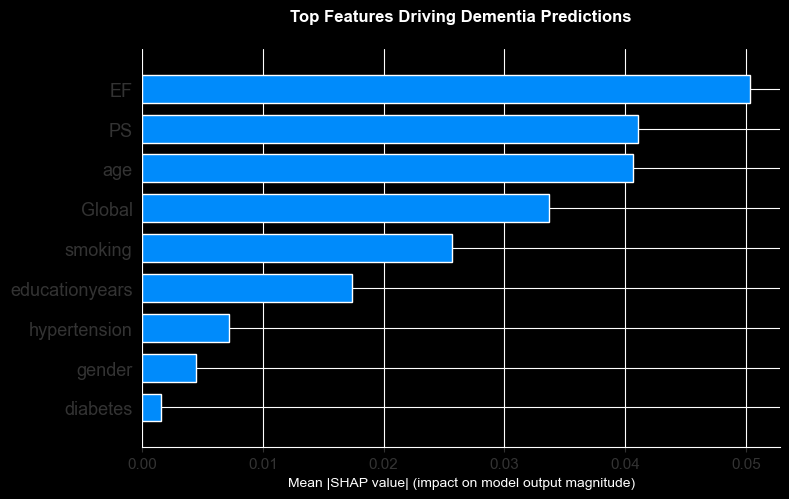

Bar chart saved as 'shap_bar_chart.png'

 Generating Beeswarm Plot...


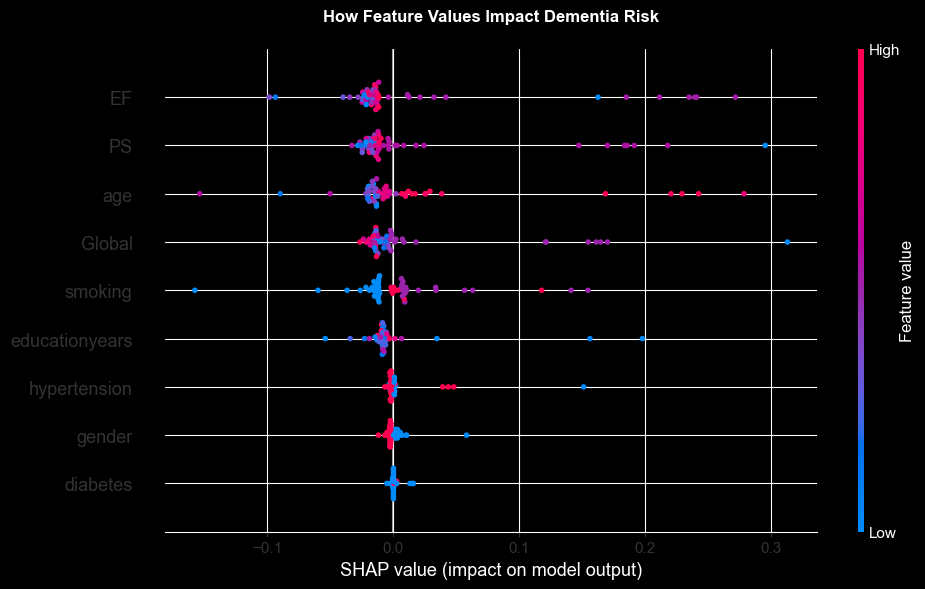

Beeswarm plot saved as 'shap_beeswarm.png'

Generating Waterfall Plot for first patient...


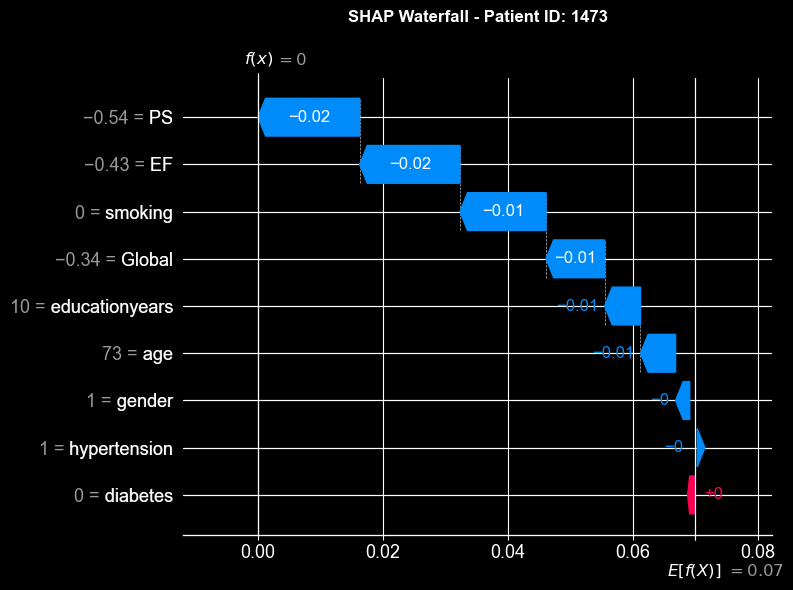

 Waterfall plot saved as 'shap_waterfall.png'

Generating Manual Bar Chart for Single Patient...

SHAP Values for Patient 1473:
       feature  shap_value  feature_value
            PS   -0.016286          -0.54
            EF   -0.016048          -0.43
       smoking   -0.013786           0.00
        Global   -0.009381          -0.34
educationyears   -0.005738          10.00
           age   -0.005619          73.00
        gender   -0.002262           1.00
  hypertension   -0.001214           1.00
      diabetes    0.000333           0.00


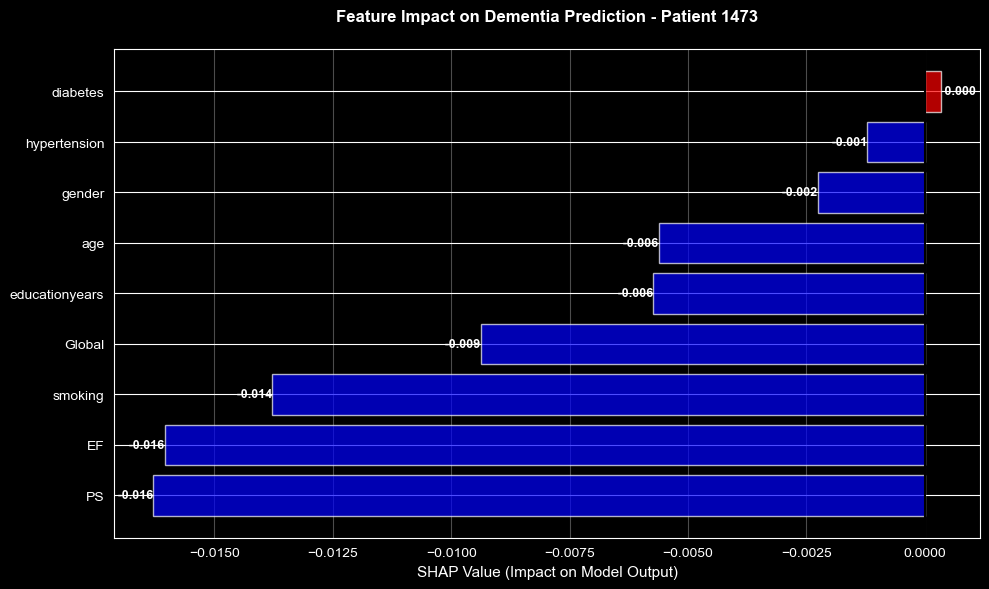

Manual bar chart saved as 'shap_patient_manual.png'

 Generating SHAP Heatmap...


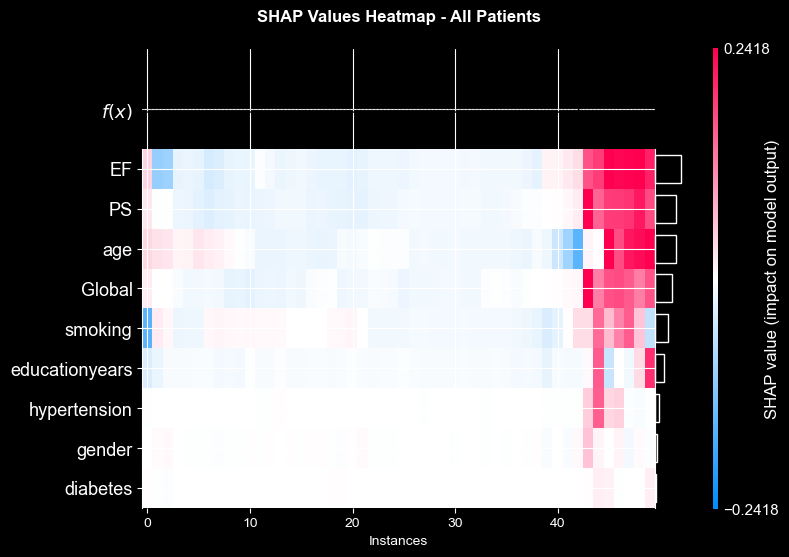

 Heatmap saved as 'shap_heatmap.png'


In [61]:
import joblib
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
model = joblib.load('../models/dementia_modelA90.joblib')

feature_names = ['age', 'gender', 'educationyears', 'EF', 'PS',
                 'Global', 'diabetes', 'smoking', 'hypertension']

# Ensure DataFrames
if isinstance(x_train, np.ndarray):
    x_train = pd.DataFrame(x_train, columns=feature_names)
if isinstance(x_test, np.ndarray):
    x_test = pd.DataFrame(x_test, columns=feature_names)

# Create explainer
print("Creating SHAP explainer...")
background_data = x_train.sample(n=100, random_state=42)
explainer = shap.Explainer(model.predict, background_data)

# Calculate SHAP values
x_to_explain = x_test.sample(n=50, random_state=42)
print("Calculating SHAP values...")
shap_values = explainer(x_to_explain)

print(f"\n🔍 SHAP Values Check:")
print(f"  Shape: {shap_values.values.shape}")
print(f"  Min: {shap_values.values.min():.6f}")
print(f"  Max: {shap_values.values.max():.6f}")
print(f"  Mean: {shap_values.values.mean():.6f}")
print(f"  Any NaN: {np.isnan(shap_values.values).any()}")
print(f"  Sample SHAP values (first patient): {shap_values.values[0]}")
print(f"  Feature names: {shap_values.feature_names}")

print("\nGenerating Feature Importance Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_to_explain, plot_type="bar", show=False)
plt.title("Top Features Driving Dementia Predictions", fontsize=12, fontweight='bold', pad=20)
plt.xlabel('Mean |SHAP value| (impact on model output magnitude)', fontsize=10)
plt.tight_layout()
plt.savefig('shap_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Bar chart saved as 'shap_bar_chart.png'")


print("\n Generating Beeswarm Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_to_explain, show=False, plot_size=None)
plt.title("How Feature Values Impact Dementia Risk", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()
print("Beeswarm plot saved as 'shap_beeswarm.png'")


print("\nGenerating Waterfall Plot for first patient...")
try:
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[0], show=False)
    plt.title(f"SHAP Waterfall - Patient ID: {x_to_explain.index[0]}",
              fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(" Waterfall plot saved as 'shap_waterfall.png'")
except Exception as e:
    print(f" Waterfall plot failed: {e}")


print("\nGenerating Manual Bar Chart for Single Patient...")
patient_idx = 0
patient_shap = shap_values.values[patient_idx]
patient_features = shap_values.feature_names
patient_data = x_to_explain.iloc[patient_idx]

# Create DataFrame for sorting
shap_df = pd.DataFrame({
    'feature': patient_features,
    'shap_value': patient_shap,
    'feature_value': patient_data.values
}).sort_values('shap_value', ascending=True)

print(f"\nSHAP Values for Patient {x_to_explain.index[patient_idx]}:")
print(shap_df.to_string(index=False))

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if v > 0 else 'blue' for v in shap_df['shap_value']]
bars = ax.barh(shap_df['feature'], shap_df['shap_value'], color=colors, alpha=0.7)

ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=11)
ax.set_title(f'Feature Impact on Dementia Prediction - Patient {x_to_explain.index[patient_idx]}',
             fontsize=12, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(shap_df.iterrows()):
    ax.text(row['shap_value'], i, f" {row['shap_value']:.3f}",
            va='center', ha='left' if row['shap_value'] > 0 else 'right',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_patient_manual.png', dpi=300, bbox_inches='tight')
plt.show()
print("Manual bar chart saved as 'shap_patient_manual.png'")


print("\n Generating SHAP Heatmap...")
plt.figure(figsize=(12, 8))
shap.plots.heatmap(shap_values, show=False)
plt.title("SHAP Values Heatmap - All Patients", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Heatmap saved as 'shap_heatmap.png'")

